# Analyzing and plotting ERA5 data

Here we plot evaporation (e), precipitation (tp) and runoff (ro) over Manipur, India

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from metpy.calc import dewpoint_from_relative_humidity
from metpy.units import units

In [4]:

ds= xr.open_dataset(
    "https://data.earthdatahub.destine.eu/era5/reanalysis-era5-land-no-antartica-v0.zarr",
    storage_options={"client_kwargs":{"trust_env":True}},
    chunks={},
    engine="zarr",
)


In [5]:
ds

<xarray.Dataset> Size: 705TB
Dimensions:              (valid_time: 664752, latitude: 1472, longitude: 3600)
Coordinates:
    depthBelowLandLayer  float64 8B ...
  * latitude             (latitude) float64 12kB 90.0 89.9 89.8 ... -57.0 -57.1
  * longitude            (longitude) float64 29kB 0.0 0.1 0.2 ... 359.8 359.9
    number               int64 8B ...
    surface              float64 8B ...
  * valid_time           (valid_time) datetime64[ns] 5MB 1950-01-01 ... 2025-...
Data variables: (12/50)
    asn                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    d2m                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    e                    (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    es                   (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    evabs                (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    evaow                (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    ...                   ...
    swvl4                (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    t2m                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    tp                   (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    tsn                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    u10                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
    v10                  (valid_time, latitude, longitude) float32 14TB dask.array<chunksize=(2880, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-10-29T11:44 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [6]:
lonW=85
lonE= 100
latN=30
latS=20

if (lonW < 0 ):
    lonW = lonW + 360
if (lonE < 0 ):
    lonE = lonE + 360
    
target_time = np.datetime64("2023-07-02")
extent = [lonW, lonE, latN, latS]

# Find the closest time in the dataset
closest_time = ds['valid_time'].sel(valid_time=target_time, method='nearest').values


In [7]:
# Extract total precipitation for the closest time
evap = ds['e'].sel(valid_time=closest_time, method='nearest')
precip = ds['tp'].sel(valid_time=closest_time, method='nearest')
runoff = ds ['ro'].sel(valid_time=closest_time, method='nearest')

In [8]:
evap

<xarray.DataArray 'e' (latitude: 1472, longitude: 3600)> Size: 21MB
dask.array<getitem, shape=(1472, 3600), dtype=float32, chunksize=(64, 64), chunktype=numpy.ndarray>
Coordinates:
    depthBelowLandLayer  float64 8B ...
  * latitude             (latitude) float64 12kB 90.0 89.9 89.8 ... -57.0 -57.1
  * longitude            (longitude) float64 29kB 0.0 0.1 0.2 ... 359.8 359.9
    number               int64 8B ...
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B 2023-07-02
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  3600
    GRIB_Ny:                                  1472
    GRIB_cfName:                              lwe_thickness_of_water_evaporat...
    GRIB_cfVarName:                           e
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               m of water equivalent
    long_name:                                Evaporation
    standard_name:                            lwe_thickness_of_water_evaporat...
    units:                                    m of water equivalent

In [11]:
print(evap['longitude'].values)
print(precip['longitude'].values)
print(runoff['longitude'].values)

[0.000e+00 1.000e-01 2.000e-01 ... 3.597e+02 3.598e+02 3.599e+02]
[0.000e+00 1.000e-01 2.000e-01 ... 3.597e+02 3.598e+02 3.599e+02]
[0.000e+00 1.000e-01 2.000e-01 ... 3.597e+02 3.598e+02 3.599e+02]


In [12]:
slice(extent[3], extent[2])

slice(20, 30, None)

In [13]:
evap.sel(latitude=np.arange(26,22.9,-0.1),method='nearest')
precip.sel(latitude=np.arange(26,22.9,-0.1),method='nearest')
runoff.sel(latitude=np.arange(26,22.9,-0.1), method='nearest')

<xarray.DataArray 'ro' (latitude: 32, longitude: 3600)> Size: 461kB
dask.array<getitem, shape=(32, 3600), dtype=float32, chunksize=(32, 64), chunktype=numpy.ndarray>
Coordinates:
    depthBelowLandLayer  float64 8B ...
  * latitude             (latitude) float64 256B 26.0 25.9 25.8 ... 23.0 22.9
  * longitude            (longitude) float64 29kB 0.0 0.1 0.2 ... 359.8 359.9
    number               int64 8B ...
    surface              float64 8B ...
    valid_time           datetime64[ns] 8B 2023-07-02
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  3600
    GRIB_Ny:                                  1472
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           ro
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               m
    long_name:                                Runoff
    standard_name:                            unknown
    units:                                    m

In [21]:
lat_range = np.arange(extent[3], extent[2],-0.1)
lon_range = np.arange(extent[0], extent[1],0.1)


In [22]:
evap_sub = evap.sel(latitude=lat_range, method='nearest').sel(longitude=lon_range, method='nearest')
precip_sub= precip.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')
runoff_sub= runoff.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')
#Convert units from meters to millimeters 
precip_mm=precip_sub*1000 
evap_mm = evap_sub * 1000  # 1 m = 1000 mm
print(evap_mm.values)

[[-2.2830963 -2.5367737 -1.9302368 ... -2.9506683 -3.0593872 -3.1528473]
 [-2.4032593 -2.2678375 -1.7299652 ... -2.9277802 -3.1642914 -3.1051636]
 [-2.4166107 -2.4337769 -2.4337769 ... -3.0918121 -3.1032562 -3.1833649]
 ...
 [-3.6182404 -3.7250519 -4.22287   ... -3.8528442 -3.8661957 -4.6310425]
 [-3.5476685 -3.643036  -4.1046143 ... -4.34494   -4.5661926 -4.7035217]
 [-3.5629272 -3.6449432 -3.616333  ... -4.627228  -4.257202  -4.34494  ]]


In [23]:
print("evap_mm shape:", evap_mm.shape)
print("lat shape:", len(lat_range))
print("lon shape:", len(lon_range))

evap_mm shape: (100, 150)
lat shape: 100
lon shape: 150


In [24]:
lat_loktak = 24.5
lon_loktak = 93.8

[[-2.2830963 -2.5367737 -1.9302368 ... -2.9506683 -3.0593872 -3.1528473]
 [-2.4032593 -2.2678375 -1.7299652 ... -2.9277802 -3.1642914 -3.1051636]
 [-2.4166107 -2.4337769 -2.4337769 ... -3.0918121 -3.1032562 -3.1833649]
 ...
 [-3.6182404 -3.7250519 -4.22287   ... -3.8528442 -3.8661957 -4.6310425]
 [-3.5476685 -3.643036  -4.1046143 ... -4.34494   -4.5661926 -4.7035217]
 [-3.5629272 -3.6449432 -3.616333  ... -4.627228  -4.257202  -4.34494  ]]


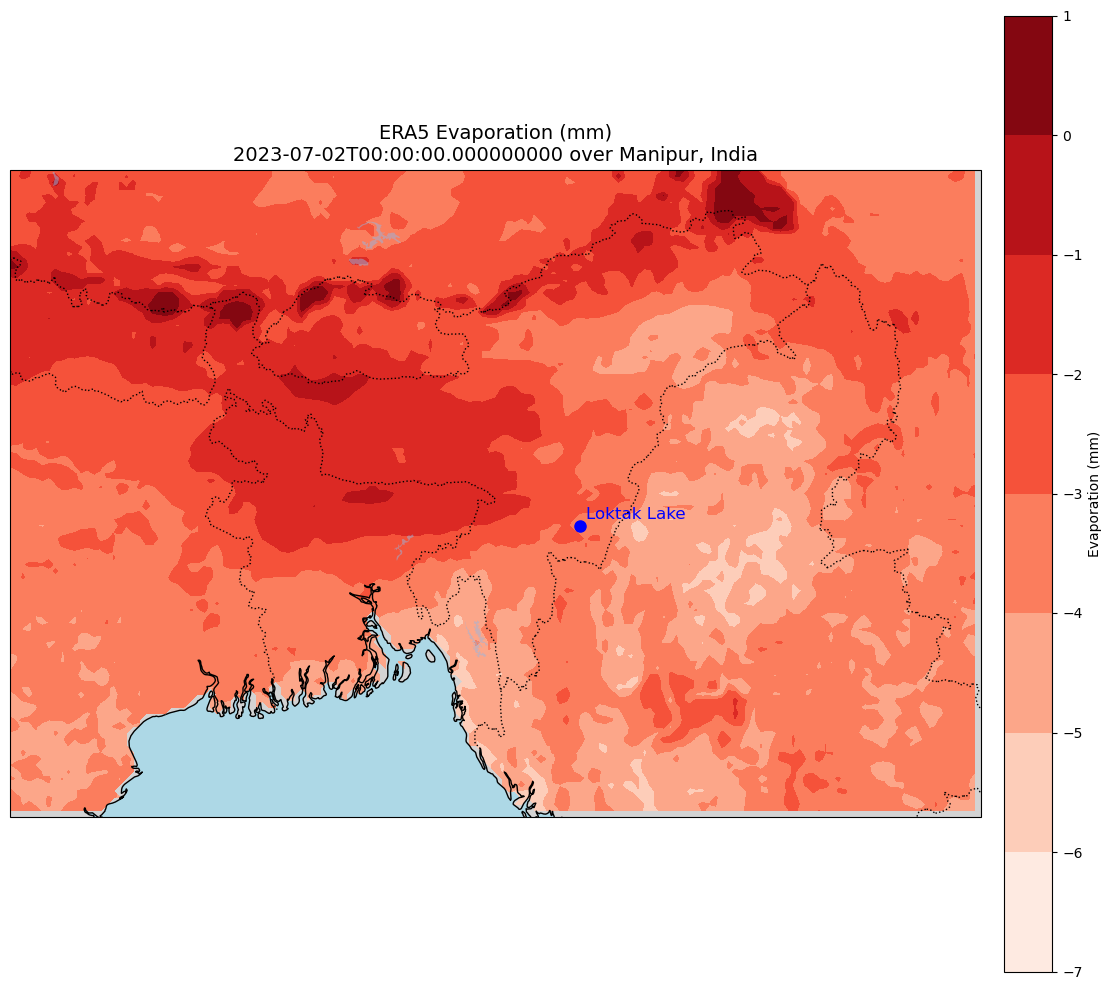

In [25]:
#slice the data based on latitude and longitude
#evap_sub = evap.sel(latitude=(np.arange(extent[3], extent[2])),method='nearest'), longitude=slice(extent[0], extent[1]#))
evap_sub = evap.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')

#Convert units from meters to millimeters 
evap_mm = evap_sub * 1000  # 1 m = 1000 mm
print(evap_mm.values)

# Create 2D lat/lon grid
# lon2d = evap_mm['longitude'].values
# lat2d = evap_mm['latitude'].values

# Define map extent for Greenland
extent = [lonW, lonE, latS,latN]  # lon_min, lon_max, lat_min, lat_max

# Create plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, alpha=0.5)

# Plot total precipitation
levels = np.linspace(0, np.max(evap_mm.values), 20)
cf = ax.contourf(evap_mm['longitude'], evap_mm['latitude'], evap_mm.transpose('latitude', 'longitude'), cmap='Reds', transform=ccrs.PlateCarree())

# Add Loktak Lake point
ax.plot(lon_loktak, lat_loktak, marker='o', color='blue', markersize=8,
        transform=ccrs.PlateCarree(), label='Loktak Lake')

# Add label text (optional)
ax.text(lon_loktak + 0.1, lat_loktak + 0.1, 'Loktak Lake', fontsize=12,
        transform=ccrs.PlateCarree(), color='blue')
#cf = ax.contourf(lon_range, lat_range, evap_mm, levels=levels, cmap='Reds', extend='max', transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("Evaporation (mm)")

# Title
plt.title(f"ERA5 Evaporation (mm)\n{str(closest_time)} over Manipur, India", fontsize=14)

plt.tight_layout()
plt.show()


## Analyzing and plotting ERA5

[[ 6.072998   6.210327   5.996704  ...  6.5994263  5.622864   4.1656494]
 [ 6.843567   6.542206   6.3171387 ...  7.205963   6.2942505  4.673004 ]
 [ 7.2135925  6.7710876  6.3323975 ...  5.2757263  4.180908   3.414154 ]
 ...
 [ 7.6179504  9.056091   9.803772  ... 20.477295  30.960083  30.273438 ]
 [ 9.262085  11.985779  13.2751465 ... 15.060425  18.325806  17.227173 ]
 [10.482788  13.61084   16.082764  ... 16.326904  10.894775   9.147644 ]]


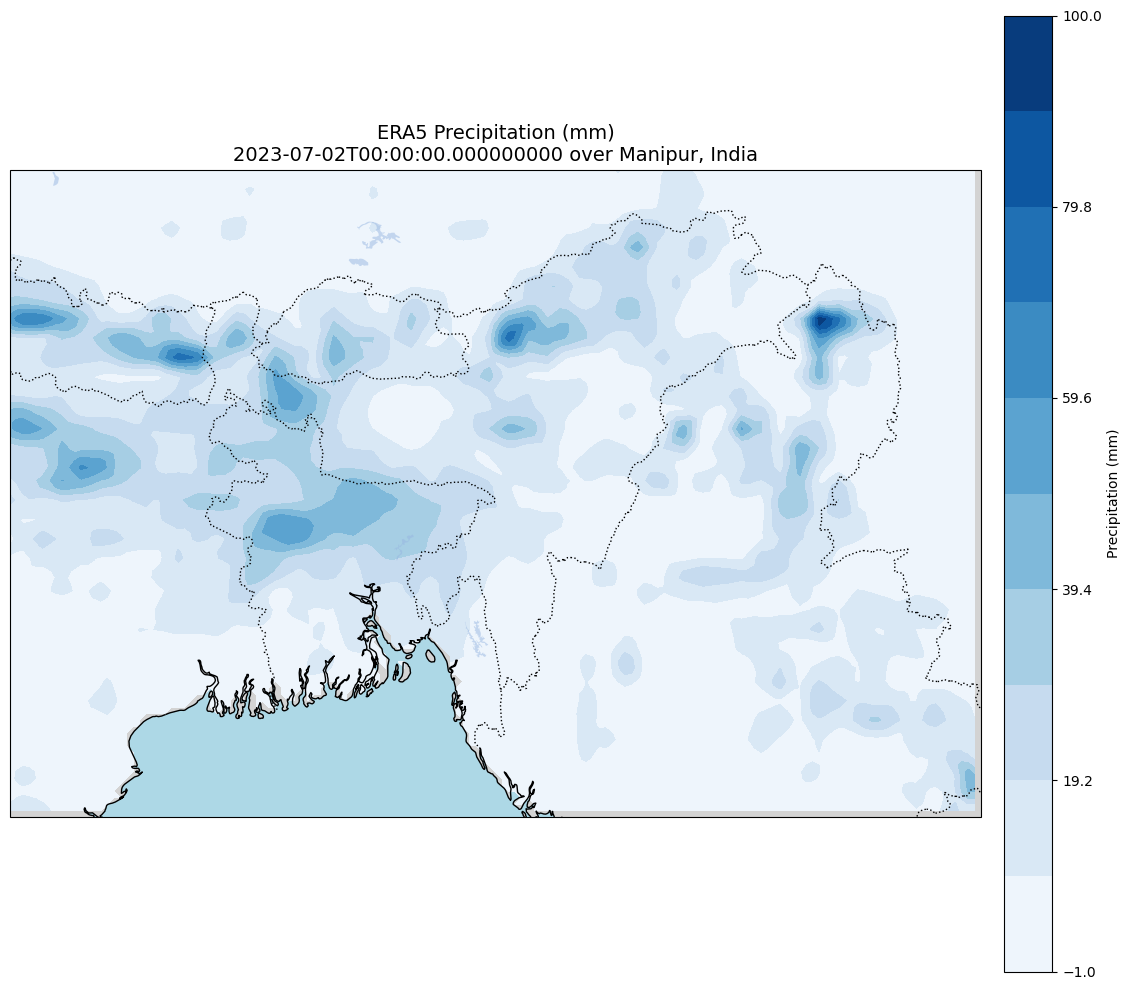

In [48]:
precip_sub = precip.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')

#Convert units from meters to millimeters 
precip_mm = precip_sub * 1000  # 1 m = 1000 mm
print(precip_mm.values)

# Create 2D lat/lon grid
# lon2d = evap_mm['longitude'].values
# lat2d = evap_mm['latitude'].values

# Define map extent for Greenland
extent = [lonW, lonE, latS,latN]  # lon_min, lon_max, lat_min, lat_max

# Create plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, alpha=0.5)

# Plot total precipitation
levels = np.linspace(-1, 100, 11)
cf = ax.contourf(precip_mm['longitude'], precip_mm['latitude'], precip_mm.transpose('latitude', 'longitude'), levels= levels, cmap='Blues', transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("Precipitation (mm)")

# Title
plt.title(f"ERA5 Precipitation (mm)\n{str(closest_time)} over Manipur, India", fontsize=14)

plt.tight_layout()
plt.show()


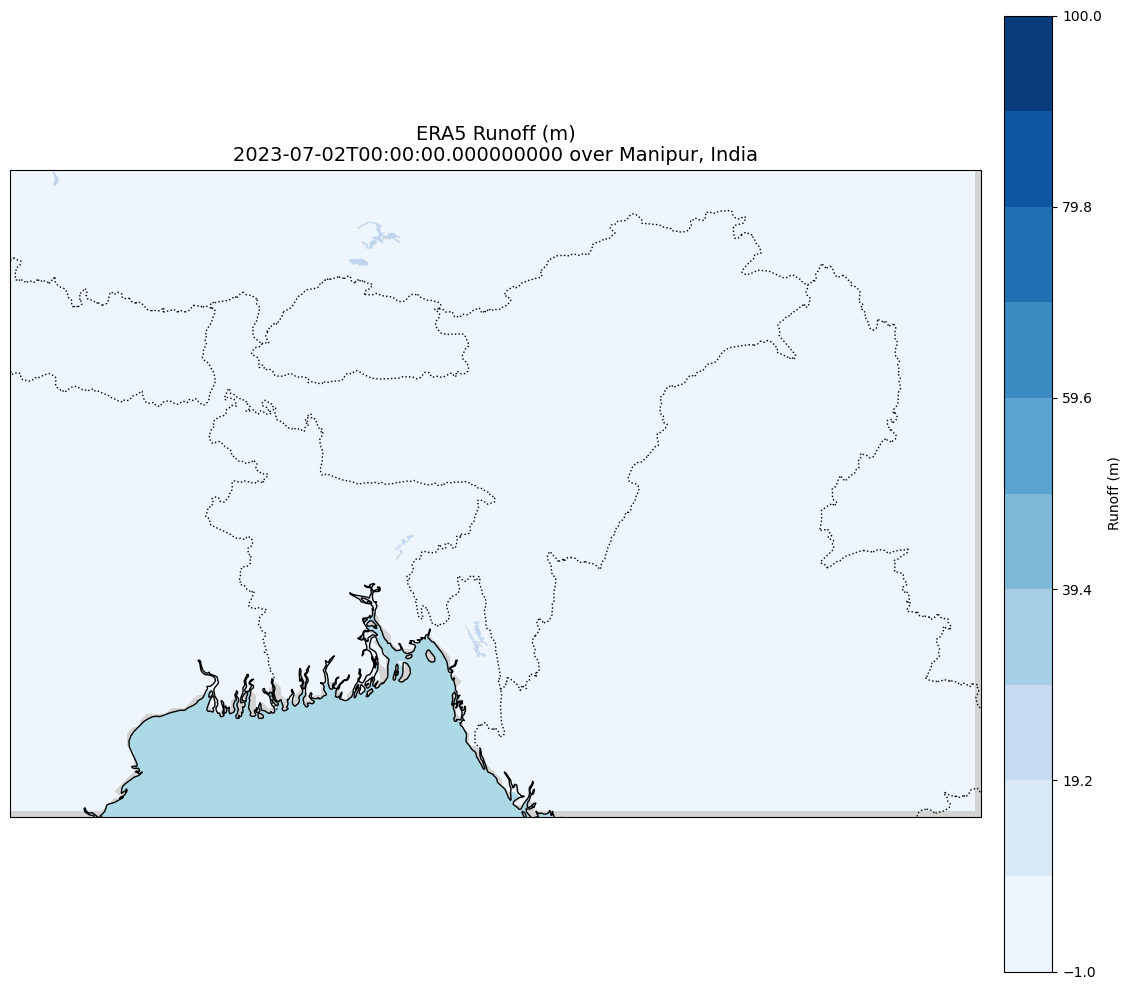

In [28]:
runoff_sub = runoff.sel(latitude=lat_range,method='nearest').sel(longitude=lon_range, method='nearest')

# Define map extent for Manipur
extent = [lonW, lonE, latS,latN]  # lon_min, lon_max, lat_min, lat_max

# Create plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.LAKES, alpha=0.5)

# Plot total precipitation
levels = np.linspace(-1, 100, 11)
cf = ax.contourf(runoff_sub['longitude'], runoff_sub['latitude'], runoff_sub.transpose('latitude', 'longitude'), levels= levels, cmap='Blues', transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("Runoff (m)")

# Title
plt.title(f"ERA5 Runoff (m)\n{str(closest_time)} over Manipur, India", fontsize=14)

plt.tight_layout()
plt.show()